In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.1 MB/s eta 0:00:00
A processar: AC...
A processar: AM...
A processar: AP...
A processar: PA...
A processar: RO...
A processar: RR...
A processar: TO...


<Figure size 1800x1200 with 0 Axes>

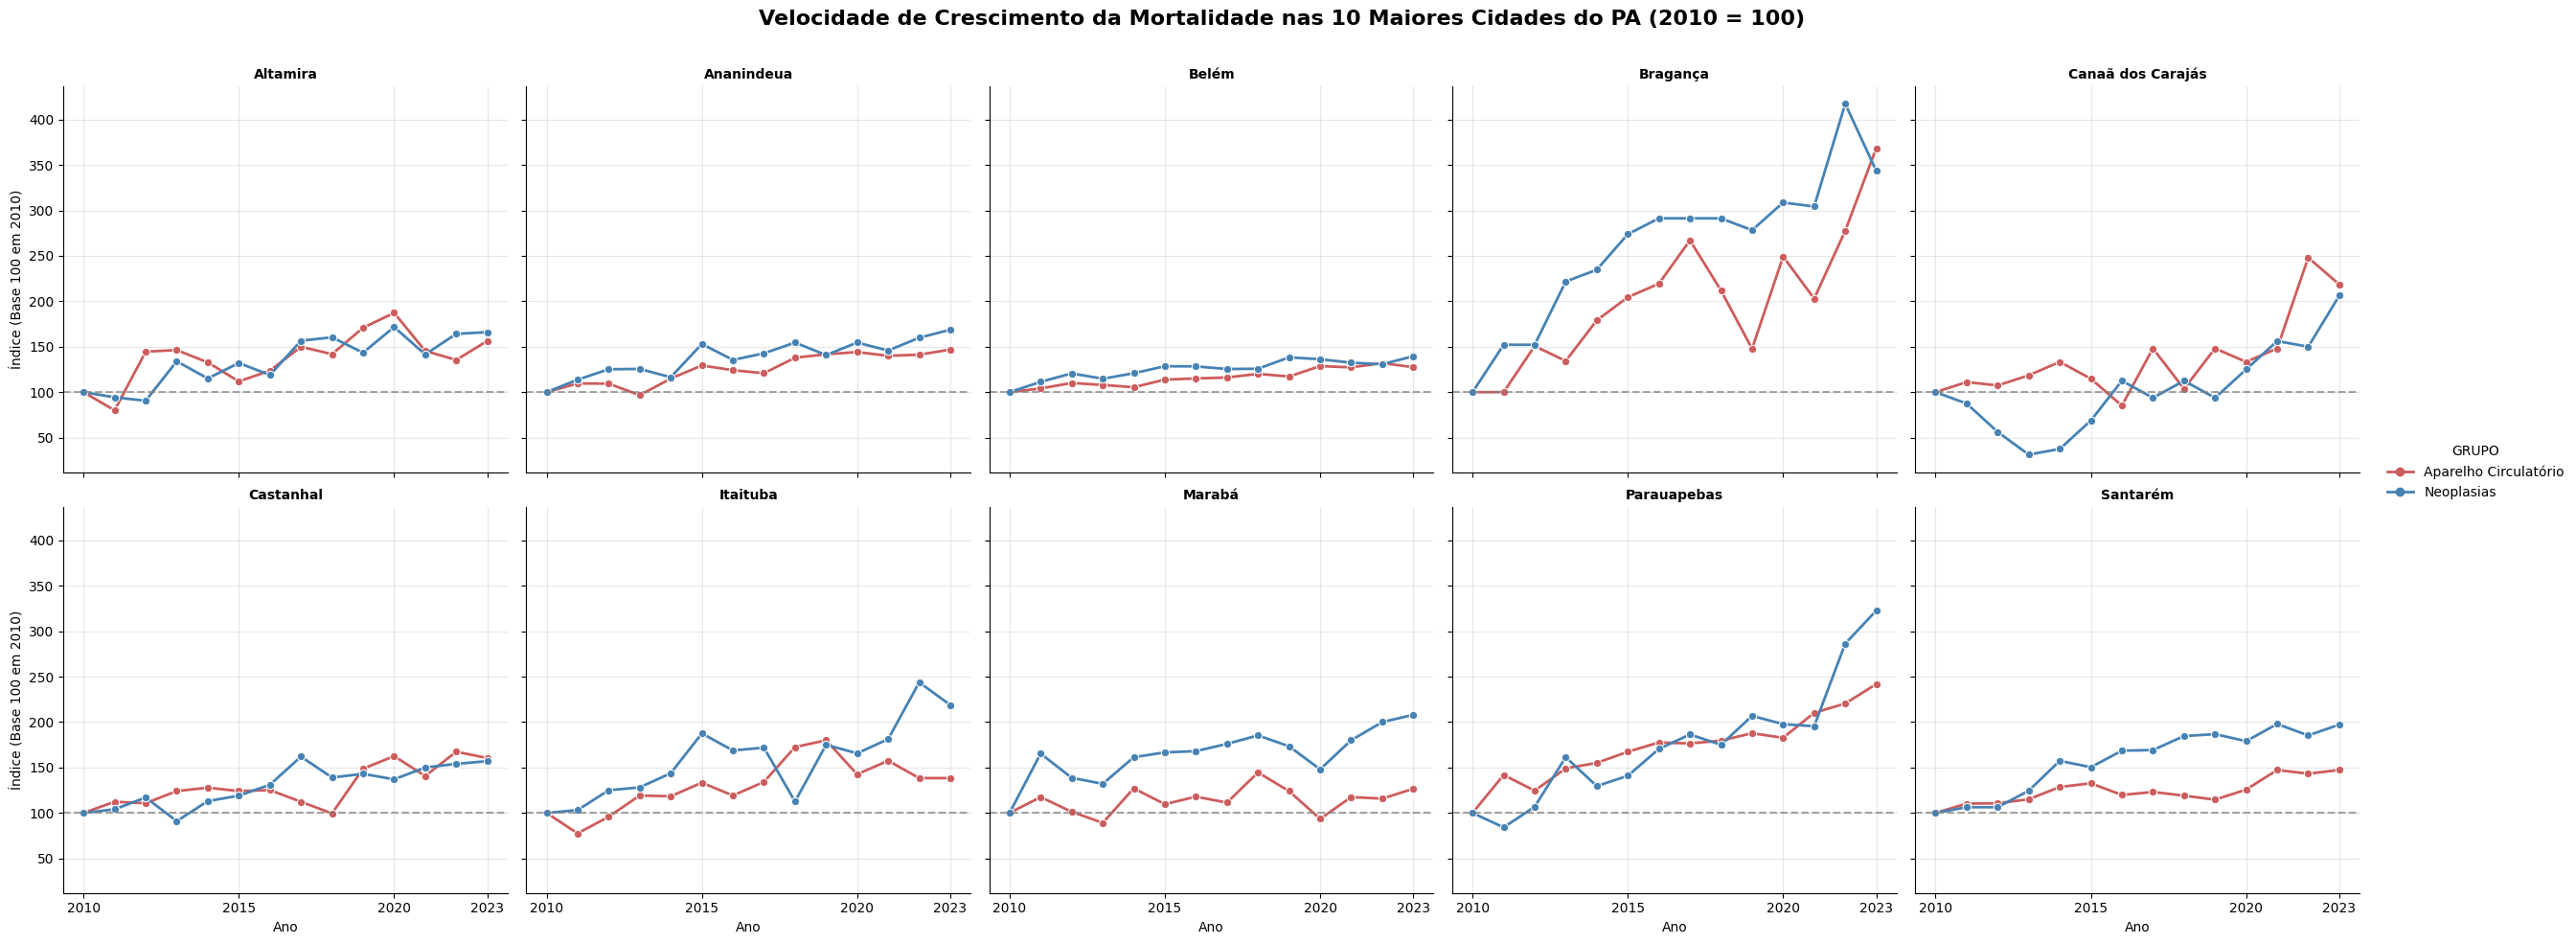


 DESTAQUES DE CRESCIMENTO NAS CIDADES (2010 vs 2023)

Top 10 cidades com maior aumento percentual geral de óbitos (Neoplasias/Circulatório):
 - Porto Acre (AC) | Aparelho Circulatório: +900.0% (Absoluto: 1.0 -> 10)
 - Mâncio Lima (AC) | Neoplasias: +700.0% (Absoluto: 1.0 -> 8)
 - Amapá (AP) | Aparelho Circulatório: +700.0% (Absoluto: 1.0 -> 8)
 - Calçoene (AP) | Aparelho Circulatório: +700.0% (Absoluto: 1.0 -> 8)
 - Coari (AM) | Neoplasias: +540.0% (Absoluto: 5.0 -> 32)
 - Porto Grande (AP) | Neoplasias: +350.0% (Absoluto: 2.0 -> 9)
 - Epitaciolândia (AC) | Neoplasias: +350.0% (Absoluto: 2.0 -> 9)
 - Tartarugalzinho (AP) | Aparelho Circulatório: +350.0% (Absoluto: 2.0 -> 9)
 - Tarauacá (AC) | Neoplasias: +333.3% (Absoluto: 6.0 -> 26)
 - Cantá (RR) | Neoplasias: +300.0% (Absoluto: 1.0 -> 4)


In [2]:
# 1. Instalação das bibliotecas necessárias
!pip install pyreaddbc dbfread -q

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

# 2. Configurações de Estados, Anos e as 10 Maiores Cidades (IBGE)
# Mapeamento do Código IBGE (6 dígitos, padrão no SIM/DATASUS) para o Nome da Cidade
CIDADES_ALVO = {
    "AC": {
        "120040": "Rio Branco", "120020": "Cruzeiro do Sul", "120043": "Sena Madureira", 
        "120050": "Tarauacá", "120030": "Feijó", "120010": "Brasileia", 
        "120039": "Porto Acre", "120025": "Epitaciolândia", "120042": "Rodrigues Alves", "120035": "Mâncio Lima"
    },
    "AM": {
        "130260": "Manaus", "130340": "Parintins", "130210": "Itacoatiara", 
        "130250": "Manacapuru", "130110": "Coari", "130420": "Tefé", 
        "130410": "Tabatinga", "130261": "Maués", "130190": "Iranduba", "130240": "Lábrea"
    },
    "AP": {
        "160030": "Macapá", "160060": "Santana", "160055": "Laranjal do Jari", 
        "160040": "Mazagão", "160053": "Porto Grande", "160050": "Oiapoque", 
        "160070": "Tartarugalzinho", "160020": "Calçoene", "160015": "Amapá", "160021": "Pedra Branca do Amapari"
    },
    "PA": {
        "150140": "Belém", "150080": "Ananindeua", "150680": "Santarém", 
        "150420": "Marabá", "150553": "Parauapebas", "150240": "Castanhal", 
        "150060": "Altamira", "150360": "Itaituba", "150215": "Canaã dos Carajás", "150170": "Bragança"
    },
    "RO": {
        "110020": "Porto Velho", "110012": "Ji-Paraná", "110004": "Cacoal", 
        "110030": "Vilhena", "110002": "Ariquemes", "110011": "Jaru", 
        "110008": "Espigão D'Oeste", "110028": "Rolim de Moura", "110010": "Guajará-Mirim", "110025": "Pimenta Bueno"
    },
    "RR": {
        "140010": "Boa Vista", "140047": "Rorainópolis", "140020": "Caracaraí", 
        "140028": "Cantá", "140015": "Bonfim", "140045": "Pacaraima", 
        "140030": "Mucajaí", "140005": "Alto Alegre", "140070": "Uiramutã", "140017": "Caroebe"
    },
    "TO": {
        "172100": "Palmas", "170210": "Araguaína", "170950": "Gurupi", 
        "171820": "Porto Nacional", "171610": "Paraíso do Tocantins", "170700": "Dianópolis", 
        "171190": "Araguatins", "170550": "Colinas do Tocantins", "172090": "Taguatinga", "171050": "Itaquaratins"
    }
}

ESTADOS = list(CIDADES_ALVO.keys())
ANOS = range(2010, 2024)

pasta_base = Path("/kaggle/working/dados_sus")
pasta_base.mkdir(exist_ok=True)

# 3. Funções de Apoio
def baixar_arquivo(url, destino):
    if destino.exists(): return True
    try:
        urlretrieve(url, destino)
        return True
    except:
        return False

def ler_e_limpar_dbc(caminho_dbc):
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))
        if caminho_dbf.exists(): os.remove(caminho_dbf)
        return df
    except:
        return None

def filtrar_causas(causa):
    if pd.isna(causa): return "Outros"
    c = str(causa).upper()
    if c.startswith('C') or (c.startswith('D') and '00' <= c[1:3] <= '48'):
        return "Neoplasias"
    if c.startswith('I'):
        return "Aparelho Circulatório"
    return "Outros"

# 4. Processamento Principal
resultados = []

for uf in ESTADOS:
    print(f"A processar: {uf}...")
    codigos_cidades = CIDADES_ALVO[uf]
    
    for ano in ANOS:
        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho_dbc = pasta_base / nome
        
        if baixar_arquivo(url, caminho_dbc):
            df_temp = ler_e_limpar_dbc(caminho_dbc)
            if df_temp is not None:
                # Padronizar a coluna de município para string e remover possíveis espaços
                df_temp["CODMUNRES"] = df_temp["CODMUNRES"].astype(str).str.strip()
                
                # Filtrar apenas as 10 maiores cidades do estado atual
                # O DATASUS costuma usar 6 dígitos para o município nesses arquivos
                df_temp["CODMUNRES_6"] = df_temp["CODMUNRES"].str[:6]
                df_filtrado = df_temp[df_temp["CODMUNRES_6"].isin(codigos_cidades.keys())].copy()
                
                if not df_filtrado.empty:
                    df_filtrado["GRUPO"] = df_filtrado["CAUSABAS"].apply(filtrar_causas)
                    df_filtrado["CIDADE"] = df_filtrado["CODMUNRES_6"].map(codigos_cidades)
                    
                    # Agrupamento por Cidade, UF e Grupo de Causa
                    resumo = df_filtrado[df_filtrado["GRUPO"] != "Outros"].groupby(["CIDADE", "GRUPO"]).size().reset_index(name="OBITOS")
                    resumo["UF"] = uf
                    resumo["ANO"] = ano
                    resultados.append(resumo)
                
                # Economiza espaço em disco no Kaggle
                if caminho_dbc.exists(): os.remove(caminho_dbc)

# 5. Consolidação e Gráficos por Cidade
if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
    df_final.to_csv("mortalidade_cidades_norte_consolidado.csv", index=False)

    # Agrupar para garantir unicidade
    df_f = df_final.groupby(["UF", "CIDADE", "ANO", "GRUPO"])["OBITOS"].sum().reset_index()
    
    # Encontrar valor de referência (2010) por Cidade/Grupo
    df_2010 = df_f[df_f["ANO"] == 2010][["CIDADE", "GRUPO", "OBITOS"]].rename(columns={"OBITOS": "OBITOS_2010"})
    
    df_ind = pd.merge(df_f, df_2010, on=["CIDADE", "GRUPO"], how="left")
    # Evitar divisão por zero caso alguma cidade menor não tenha registro em 2010
    df_ind = df_ind[df_ind["OBITOS_2010"] > 0]
    df_ind["INDICE_CRESCIMENTO"] = (df_ind["OBITOS"] / df_ind["OBITOS_2010"]) * 100

    # Exemplo de Visualização: Gráfico para o estado do Pará (PA) como demonstração
    # Como são 70 cidades no total, plotar todas juntas viraria o caos. Vamos gerar o gráfico do maior estado.
    estado_exemplo = "PA"
    df_plot = df_ind[df_ind["UF"] == estado_exemplo]
    
    plt.figure(figsize=(18, 12))
    g = sns.relplot(
        data=df_plot,
        x="ANO", 
        y="INDICE_CRESCIMENTO", 
        hue="GRUPO", 
        col="CIDADE", 
        col_wrap=5, # 10 cidades quebram perfeitamente em 2 linhas de 5
        kind="line", 
        marker="o", 
        linewidth=2,
        palette=["#CD5C5C", "#4682B4"]
    )
    
    g.set_titles("{col_name}", fontweight='bold')
    g.set_axis_labels("Ano", "Índice (Base 100 em 2010)")
    
    for ax in g.axes.flat:
        ax.axhline(100, color="gray", linestyle="--", alpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([2010, 2015, 2020, 2023])
        
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Velocidade de Crescimento da Mortalidade nas 10 Maiores Cidades do {estado_exemplo} (2010 = 100)", fontsize=16, fontweight='bold')
    plt.show()

    # Ranking de Crescimento das Cidades
    print("\n" + "="*80)
    print(" DESTAQUES DE CRESCIMENTO NAS CIDADES (2010 vs 2023)")
    print("="*80)
    
    df_2023 = df_ind[df_ind["ANO"] == 2023].copy()
    df_2023["VARIACAO_PERC"] = df_2023["INDICE_CRESCIMENTO"] - 100
    ranking = df_2023.sort_values(by="VARIACAO_PERC", ascending=False)
    
    print("\nTop 10 cidades com maior aumento percentual geral de óbitos (Neoplasias/Circulatório):")
    for _, row in ranking.head(10).iterrows():
        print(f" - {row['CIDADE']} ({row['UF']}) | {row['GRUPO']}: +{row['VARIACAO_PERC']:.1f}% (Absoluto: {row['OBITOS_2010']} -> {row['OBITOS']})")

else:
    print("Nenhum dado processado.")


A processar o estado: ES...
  -> Ano 2010... OK
  -> Ano 2011... OK
  -> Ano 2012... OK
  -> Ano 2013... OK
  -> Ano 2014... OK
  -> Ano 2015... OK
  -> Ano 2016... OK
  -> Ano 2017... OK
  -> Ano 2018... OK
  -> Ano 2019... OK
  -> Ano 2020... OK
  -> Ano 2021... OK
  -> Ano 2022... OK
  -> Ano 2023... OK

A processar o estado: MG...
  -> Ano 2010... OK
  -> Ano 2011... OK
  -> Ano 2012... OK
  -> Ano 2013... OK
  -> Ano 2014... OK
  -> Ano 2015... OK
  -> Ano 2016... OK
  -> Ano 2017... OK
  -> Ano 2018... OK
  -> Ano 2019... OK
  -> Ano 2020... OK
  -> Ano 2021... OK
  -> Ano 2022... OK
  -> Ano 2023... OK

A processar o estado: RJ...
  -> Ano 2010... OK
  -> Ano 2011... OK
  -> Ano 2012... OK
  -> Ano 2013... OK
  -> Ano 2014... OK
  -> Ano 2015... OK
  -> Ano 2016... OK
  -> Ano 2017... OK
  -> Ano 2018... OK
  -> Ano 2019... OK
  -> Ano 2020... OK
  -> Ano 2021... OK
  -> Ano 2022... OK
  -> Ano 2023... OK

A processar o estado: SP...
  -> Ano 2010... OK
  -> Ano 2011... OK
  ->

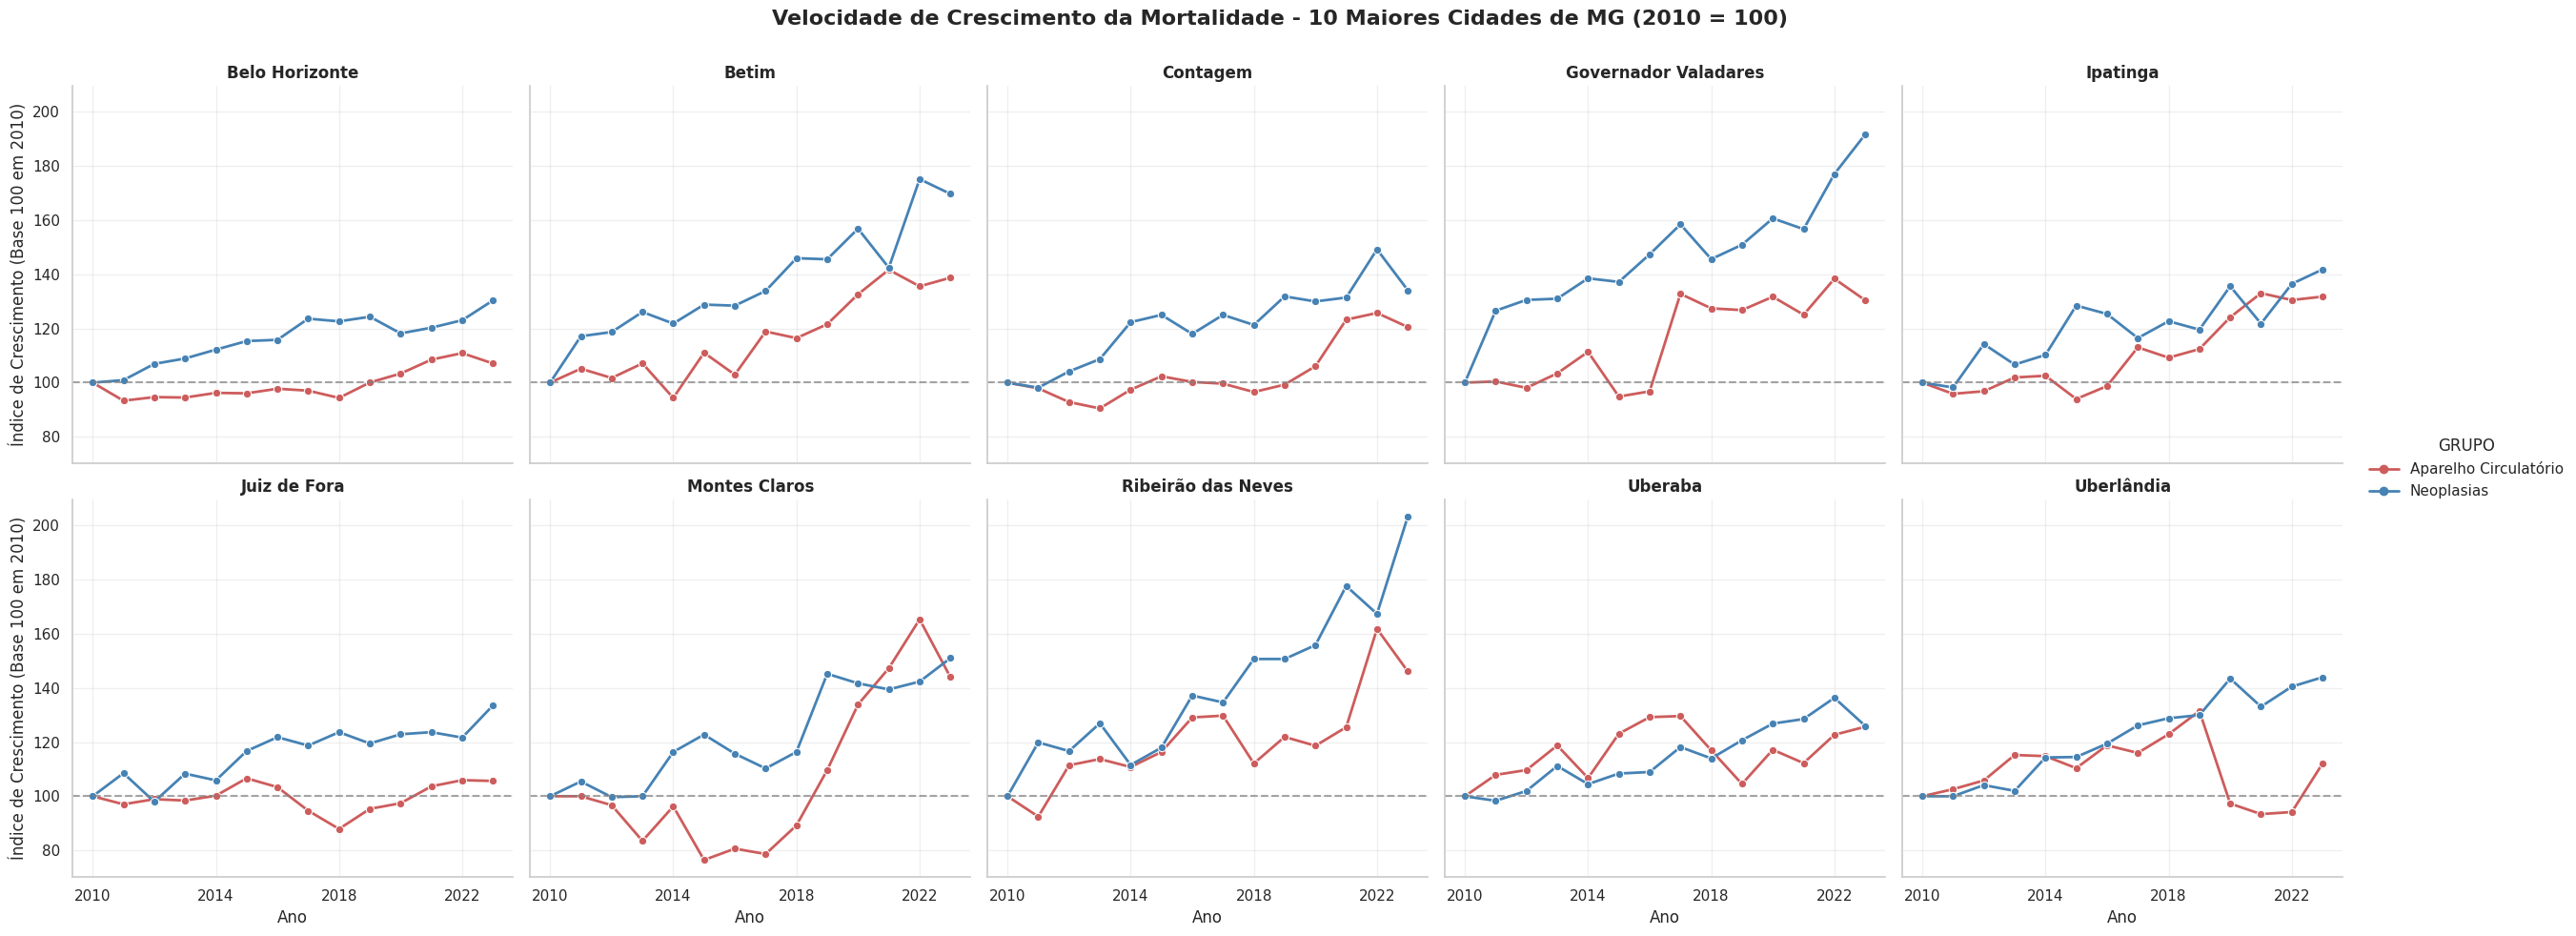


 RANKING DO CRESCIMENTO ACUMULADO (2010 vs 2023) NAS CIDADES DO SUDESTE

-> Grupo: Aparelho Circulatório
   São Mateus (ES): cresceu 59.5% em relação a 2010 (Absoluto: 153 -> 244)
   Sorocaba (SP): cresceu 52.5% em relação a 2010 (Absoluto: 906 -> 1382)
   Ribeirão das Neves (MG): cresceu 46.1% em relação a 2010 (Absoluto: 306 -> 447)
   Montes Claros (MG): cresceu 44.0% em relação a 2010 (Absoluto: 455 -> 655)
   Serra (ES): cresceu 39.0% em relação a 2010 (Absoluto: 559 -> 777)
   Betim (MG): cresceu 38.7% em relação a 2010 (Absoluto: 408 -> 566)
   Mauá (SP): cresceu 37.6% em relação a 2010 (Absoluto: 671 -> 923)
   Ipatinga (MG): cresceu 31.7% em relação a 2010 (Absoluto: 315 -> 415)
   Governador Valadares (MG): cresceu 30.4% em relação a 2010 (Absoluto: 467 -> 609)
   São Bernardo do Campo (SP): cresceu 27.7% em relação a 2010 (Absoluto: 1374 -> 1755)

-> Grupo: Neoplasias
   Ribeirão das Neves (MG): cresceu 103.2% em relação a 2010 (Absoluto: 156 -> 317)
   Linhares (ES): cresc

In [3]:
# 1. Instalação das bibliotecas necessárias
!pip install pyreaddbc dbfread -q

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve
from pyreaddbc import dbc2dbf
from dbfread import DBF

# 2. Configurações de Estados, Anos e as 10 Maiores Cidades do Sudeste (IBGE)
# Mapeamento do Código IBGE de 6 dígitos para o Nome da Cidade
CIDADES_ALVO = {
    "ES": {
        "320530": "Vitória", "320520": "Vila Velha", "320500": "Serra", 
        "320130": "Cariacica", "320120": "Cachoeiro de Itapemirim", "320320": "Linhares", 
        "320490": "São Mateus", "320240": "Guarapari", "320150": "Colatina", "320016": "Aracruz"
    },
    "MG": {
        "310620": "Belo Horizonte", "317020": "Uberlândia", "311860": "Contagem", 
        "313670": "Juiz de Fora", "310670": "Betim", "314330": "Montes Claros", 
        "315460": "Ribeirão das Neves", "317010": "Uberaba", "312770": "Governador Valadares", "313130": "Ipatinga"
    },
    "RJ": {
        "330455": "Rio de Janeiro", "330490": "São Gonçalo", "330170": "Duque de Caxias", 
        "330330": "Nova Iguaçu", "330100": "Campos dos Goytacazes", "330045": "Belford Roxo", 
        "330510": "São João de Meriti", "330350": "Niterói", "330390": "Petrópolis", "330610": "Volta Redonda"
    },
    "SP": {
        "355030": "São Paulo", "351880": "Guarulhos", "350950": "Campinas", 
        "354870": "São Bernardo do Campo", "354780": "Santo André", "355100": "São José dos Campos", 
        "354340": "Ribeirão Preto", "353440": "Osasco", "355220": "Sorocaba", "352940": "Mauá"
    }
}

ESTADOS = list(CIDADES_ALVO.keys())
ANOS = range(2010, 2024)

# No Kaggle, usamos o diretório /kaggle/working/ para salvar ficheiros
pasta_base = Path("/kaggle/working/dados_sus")
pasta_base.mkdir(exist_ok=True)

# 3. Funções de Apoio
def baixar_arquivo(url, destino):
    if destino.exists(): return True
    try:
        urlretrieve(url, destino)
        return True
    except:
        return False

def ler_e_limpar_dbc(caminho_dbc):
    """Converte DBC para DBF, lê e apaga o DBF para poupar espaço"""
    caminho_dbf = caminho_dbc.with_suffix(".dbf")
    try:
        dbc2dbf(str(caminho_dbc), str(caminho_dbf))
        df = pd.DataFrame(iter(DBF(str(caminho_dbf), encoding="latin1")))
        if caminho_dbf.exists(): os.remove(caminho_dbf)
        return df
    except:
        return None

def filtrar_causas(causa):
    if pd.isna(causa): return "Outros"
    c = str(causa).upper()
    if c.startswith('C') or (c.startswith('D') and '00' <= c[1:3] <= '48'):
        return "Neoplasias"
    if c.startswith('I'):
        return "Aparelho Circulatório"
    return "Outros"

# 4. Processamento Principal
resultados = []

for uf in ESTADOS:
    print(f"\nA processar o estado: {uf}...")
    codigos_cidades = CIDADES_ALVO[uf]
    
    for ano in ANOS:
        nome = f"DO{uf}{ano}.dbc"
        url = f"ftp://ftp.datasus.gov.br/dissemin/publicos/SIM/CID10/DORES/{nome}"
        caminho_dbc = pasta_base / nome
        
        print(f"  -> Ano {ano}...", end="", flush=True)
        if baixar_arquivo(url, caminho_dbc):
            df_temp = ler_e_limpar_dbc(caminho_dbc)
            if df_temp is not None:
                # Padronizar a coluna de código do município de residência para string
                df_temp["CODMUNRES"] = df_temp["CODMUNRES"].astype(str).str.strip()
                df_temp["CODMUNRES_6"] = df_temp["CODMUNRES"].str[:6]
                
                # Filtrar apenas as 10 maiores cidades do estado atual
                df_filtrado = df_temp[df_temp["CODMUNRES_6"].isin(codigos_cidades.keys())].copy()
                
                if not df_filtrado.empty:
                    df_filtrado["GRUPO"] = df_filtrado["CAUSABAS"].apply(filtrar_causas)
                    df_filtrado["CIDADE"] = df_filtrado["CODMUNRES_6"].map(codigos_cidades)
                    
                    # Agrupar dados limpos por Cidade e Grupo de Doença
                    resumo = df_filtrado[df_filtrado["GRUPO"] != "Outros"].groupby(["CIDADE", "GRUPO"]).size().reset_index(name="OBITOS")
                    resumo["UF"] = uf
                    resumo["ANO"] = ano
                    resultados.append(resumo)
                
                # CRÍTICO PARA O SUDESTE: Apagar o .dbc original para poupar espaço em disco no Kaggle
                if caminho_dbc.exists(): os.remove(caminho_dbc)
                print(" OK")
            else:
                print(" Erro na leitura")
        else:
            print(" Erro no download (Arquivo indisponível)")

# 5. Consolidação e Gráficos por Cidade
# ==============================================================================
# 5. CONSOLIDAÇÃO, NORMALIZAÇÃO E ANÁLISE COMPLEMENTAR DE CRESCIMENTO
# ==============================================================================
if resultados:
    df_final = pd.concat(resultados, ignore_index=True)
    df_final.to_csv("mortalidade_sudeste_cidades_consolidado.csv", index=False)

    # Garantir a consolidação correta
    df_f = df_final.groupby(["UF", "CIDADE", "ANO", "GRUPO"])["OBITOS"].sum().reset_index()
    
    # Encontrar o valor de referência (Ano 2010) para cada Cidade e cada GRUPO
    df_2010 = df_f[df_f["ANO"] == 2010][["CIDADE", "GRUPO", "OBITOS"]].rename(columns={"OBITOS": "OBITOS_2010"})
    
    # Mesclar e calcular o índice (Valor do Ano / Valor de 2010) * 100
    df_ind = pd.merge(df_f, df_2010, on=["CIDADE", "GRUPO"], how="left")
    df_ind = df_ind[df_ind["OBITOS_2010"] > 0] # Remove inconsistências de divisão por zero
    df_ind["INDICE_CRESCIMENTO"] = (df_ind["OBITOS"] / df_ind["OBITOS_2010"]) * 100

    # --------------------------------------------------------------------------
    # VISUALIZAÇÃO: Exemplo focado nas 10 maiores cidades de um Estado (ex: MG)
    # Como monitorar 40 cidades ao mesmo tempo poluía o gráfico, filtramos por UF
    # --------------------------------------------------------------------------
    estado_visualizacao = "MG"
    df_plot = df_ind[df_ind["UF"] == estado_visualizacao]
    
    sns.set_theme(style="whitegrid")
    g = sns.relplot(
        data=df_plot,
        x="ANO", 
        y="INDICE_CRESCIMENTO", 
        hue="GRUPO", 
        col="CIDADE", 
        col_wrap=5, # Divide em grade de 5 colunas (2 linhas perfeitas para 10 cidades)
        kind="line", 
        marker="o", 
        linewidth=2,
        palette=["#CD5C5C", "#4682B4"]
    )
    
    g.set_titles("{col_name}", fontweight='bold')
    g.set_axis_labels("Ano", "Índice de Crescimento (Base 100 em 2010)")
    
    for ax in g.axes.flat:
        ax.axhline(100, color="gray", linestyle="--", alpha=0.7)
        ax.grid(True, alpha=0.3)
        ax.set_xticks([2010, 2014, 2018, 2022])
        
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(f"Velocidade de Crescimento da Mortalidade - 10 Maiores Cidades de {estado_visualizacao} (2010 = 100)", fontsize=16, fontweight='bold')
    plt.show()

    # --------------------------------------------------------------------------
    # RANKING DO CRESCIMENTO ACUMULADO NAS CIDADES DO SUDESTE (2010 vs 2023)
    # --------------------------------------------------------------------------
    print("\n" + "="*80)
    print(" RANKING DO CRESCIMENTO ACUMULADO (2010 vs 2023) NAS CIDADES DO SUDESTE")
    print("="*80)
    
    df_2023 = df_ind[df_ind["ANO"] == 2023].copy()
    df_2023["VARIACAO_PERC"] = df_2023["INDICE_CRESCIMENTO"] - 100
    
    ranking = df_2023.sort_values(by=["GRUPO", "VARIACAO_PERC"], ascending=[True, False])
    for grupo in ranking["GRUPO"].unique():
        print(f"\n-> Grupo: {grupo}")
        df_g = ranking[ranking["GRUPO"] == grupo]
        # Mostra o top 10 do ranking geral de cidades para cada causa
        for _, row in df_g.head(10).iterrows():
            print(f"   {row['CIDADE']} ({row['UF']}): cresceu {row['VARIACAO_PERC']:.1f}% em relação a 2010 (Absoluto: {row['OBITOS_2010']} -> {row['OBITOS']})")

else:
    print("Nenhum dado processado.")

DADOS BAIXADOS DA REGIÃO SUDESTE 